## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import data_profiling
import tqdm as notebook_tqdm
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

In [2]:
data = pd.read_csv(r"C:\Users\Asma\Documents\asma.csv")
data

,order_id,customer_id,order_date,country,category,product,quantity,unit_price,total_amount,status,payment_method,is_returned
0,ORD-004208,CUST-6426,22/07/2022,canada,Clothing,Notebook Set,4,$14.95,$59.80,Shipped,PayPal,TRUE
1,ORD-006584,NaN,10-12-2023,NaN,NaN,Backpack,-2,NaN,NaN,Shipped,Cash,True
2,ORD-013539,NaN,26/07/2023,NaN,NaN,Travel Mug,9,NaN,NaN,Delivered,PayPal,1
3,ORD-038448,CUST-2286,02-18-2022,Germany,clothing,Bluetooth Speaker,2,$59.95,$119.90,shipped,Cash,No
4,ORD-022268,CUST-6074,18/06/2024,Australia,Clothing,Office Chair,5,$149.99,$749.95,pending,Bank Transfer,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
50995,ORD-011285,CUST-1678,14/11/2022,USA,ELECTRONICS,Resistance Bands,1,$24.95,$24.95,delivered,Cash,no
50996,ORD-044733,CUST-5264,07-16-2022,U.S.A,books,Backpack,4,$54.99,$219.96,cancelled,Bank Transfer,False
50997,ORD-038159,CUST-0710,2023-06-04,United Kingdom,books,USB Hub,2,$29.99,$59.98,Delivered,Cash,FALSE
50998,ORD-000861,CUST-4352,14/02/2024,DE,electronics,Python Programming Book,1,$44.99,$44.99,Cancelled,Cash,No


## 3. Exploaring the data

### 3.1 Dataset Dimensions

In [3]:
data.shape

(51000, 12)

### 3.2 Data Types

In [4]:
data.dtypes

order_id          object
customer_id       object
order_date        object
country           object
category          object
product           object
quantity           int64
unit_price        object
total_amount      object
status            object
payment_method    object
is_returned       object
dtype: object

### 3.3 Data Report

In [5]:
profile = data_profiling.ProfileReport(data, title="Profiling Report")
profile.to_file("report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:03<00:00,  3.31it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### 3.4 Data Columns

In [6]:
data.columns

Index(['order_id', 'customer_id', 'order_date', 'country', 'category',
       'product', 'quantity', 'unit_price', 'total_amount', 'status',
       'payment_method', 'is_returned'],
      dtype='object')

### 3.5 Missing Data

In [7]:
print("The missing values in each columns is :\n",data.isnull().sum())

The missing values in each columns is :
 order_id             0
customer_id       2033
order_date           0
country           2540
category          3052
product              0
quantity             0
unit_price        2033
total_amount      2033
status               0
payment_method       0
is_returned          0
dtype: int64


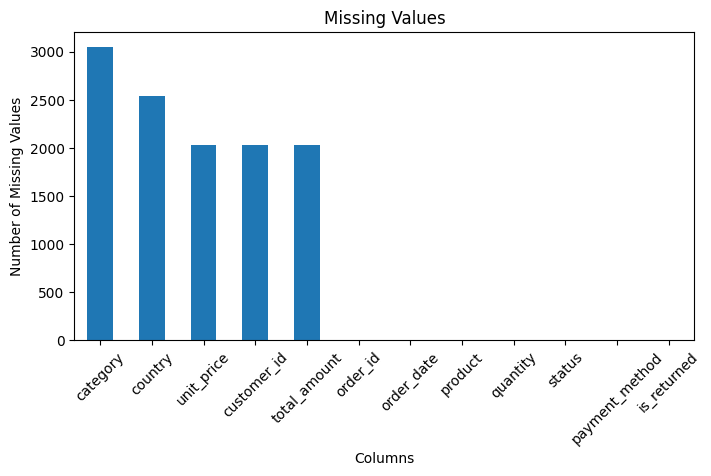

In [8]:

missing = data.isna().sum()
missing = missing.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
missing.plot(kind="bar")
plt.title("Missing Values")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()

### 3.6 Duplicated Data

In [9]:
dup = data.duplicated().sum()
print("Duplicated data :", dup)

Duplicated data : 1000


### 3.7 Inconsistent Values

In [10]:
col = ['order_date', 'country', 'category',
       'product', 'quantity', 'status',
       'payment_method', 'is_returned']
for col in data[col]:
    print("***********************************************************")
    print("column name is :",col)
    print(data[col].unique())

***********************************************************
column name is : order_date
['22/07/2022' '10-12-2023' '26/07/2023' ... '06 Oct 2022' '18 Apr 2024'
 '01 Jun 2024']
***********************************************************
column name is : country
['canada' nan 'Germany' 'Australia' 'US' 'United Kingdom' 'AUS'
 'United States' 'U.K.' 'germany' 'U.S.A' 'UK' 'australia' 'Canada' 'DE'
 'CANADA' 'USA']
***********************************************************
column name is : category
['Clothing' nan ' clothing' 'Home & Garden' 'books' 'SPORTS'
 'Home and Garden' 'home & garden' 'Sports ' 'BOOKS' 'clothing ' 'Books'
 'ELECTRONICS' 'electronics' 'Sports' 'Electronics']
***********************************************************
column name is : product
['Notebook Set' 'Backpack' 'Travel Mug' 'Bluetooth Speaker' 'Office Chair'
 'Coffee Table' 'LED Strip Lights' 'Python Programming Book'
 'Laptop Stand' 'Phone Case' 'USB Hub' 'Resistance Bands'
 'Wireless Headphones' 'Water Bot

### 3.8 Invalid Values

In [11]:
data.columns

Index(['order_id', 'customer_id', 'order_date', 'country', 'category',
       'product', 'quantity', 'unit_price', 'total_amount', 'status',
       'payment_method', 'is_returned'],
      dtype='object')

In [12]:
data[['order_date','quantity','unit_price','total_amount']]

,order_date,quantity,unit_price,total_amount
0,22/07/2022,4,$14.95,$59.80
1,10-12-2023,-2,NaN,NaN
2,26/07/2023,9,NaN,NaN
3,02-18-2022,2,$59.95,$119.90
4,18/06/2024,5,$149.99,$749.95
...,...,...,...,...
50995,14/11/2022,1,$24.95,$24.95
50996,07-16-2022,4,$54.99,$219.96
50997,2023-06-04,2,$29.99,$59.98
50998,14/02/2024,1,$44.99,$44.99


we can notice the date columns with diffrent format and that quantity contain negative numbers unit_price with dollar signs and coma and total amount need to re be calculated since the qaunityty and untie price are wrong

In [13]:
print("Rows with zero quantity:", (data["quantity"] == 0).sum())

Rows with zero quantity: 304


In [14]:
data[data["quantity"] == 0][[
    "order_id",
    "product",
    "quantity",
    "unit_price",
    "total_amount",
    "status",
    "is_returned"
]].head(20)

,order_id,product,quantity,unit_price,total_amount,status,is_returned
193,ORD-040428,Resistance Bands,0,$24.95,$0.00,cancelled,1
449,ORD-049440,Phone Case,0,$14.99,$0.00,Delivered,No
638,ORD-013603,Yoga Mat,0,$29.99,$0.00,cancelled,0
849,ORD-015018,Notebook Set,0,$14.95,$0.00,Delivered,No
887,ORD-029559,USB Hub,0,$29.99,$0.00,Shipped,Y
971,ORD-040182,Laptop Stand,0,$39.99,$0.00,Cancelled,no
994,ORD-030835,Yoga Mat,0,$29.99,$0.00,Shipped,TRUE
1139,ORD-034549,LED Strip Lights,0,$24.99,$0.00,Shipped,0
1191,ORD-037976,Sunglasses,0,NaN,NaN,DELIVERED,yes
1322,ORD-002190,Python Programming Book,0,NaN,NaN,pending,No


* Approximately 300 rows contained quantity = 0 we re going to remove the 300 row of 0 quantity cause they they are not meaningful for the sales analysis

## 4. Data Cleaning

now that we identified the problems we're going to work on cleaning the data in this part

In [15]:
df = data[data["quantity"] > 0].copy()

### 4.1 Remove Duplicates

In [16]:
print("data set dimension : ", df.shape)
df = df.drop_duplicates()
print("data set dimension after removing duplicate : ", df.shape)

data set dimension :  (50494, 12)
data set dimension after removing duplicate :  (49500, 12)


### Fix incorrect formats / values

In [17]:
pd.set_option("display.max_rows", 100)
print(df[["quantity","unit_price","total_amount"]]) 

       quantity unit_price total_amount
0             4     $14.95       $59.80
2             9        NaN          NaN
3             2     $59.95      $119.90
4             5    $149.99      $749.95
5             2        NaN          NaN
...         ...        ...          ...
50995         1     $24.95       $24.95
50996         4     $54.99      $219.96
50997         2     $29.99       $59.98
50998         1     $44.99       $44.99
50999         8     $34.95      $279.60

[49500 rows x 3 columns]


after checking that the negative numbers arenegative by error we normlaise them

In [18]:
print("number of negative lignes in quantity : ",(df["quantity"] < 0).sum())

number of negative lignes in quantity :  0


In [19]:
df["quantity"] = df["quantity"].abs()
print("number of negative lignes in quantity : ",(df["quantity"] < 0).sum())

number of negative lignes in quantity :  0


* Next that we fixed the error in quantity we and normalize tge values in unite price that containe dolar and euro sign and coma

In [20]:
df["unit_price"] = df["unit_price"].str.replace(r"[$]", "", regex=True)
df["total_amount"] = df["total_amount"].str.replace(r"[$]", "", regex=True)
df["total_amount"] = df["total_amount"].str.replace(r",", "", regex=True).astype(float)

In [21]:
df["total_amount"] = df["total_amount"].abs()
print("number of negative lignes in total_amount : ",(df["total_amount"] < 0).sum())

number of negative lignes in total_amount :  0


* next correcting the date format 

In [22]:
print(df["order_date"]) 

0        22/07/2022
2        26/07/2023
3        02-18-2022
4        18/06/2024
5        03/02/2023
            ...    
50995    14/11/2022
50996    07-16-2022
50997    2023-06-04
50998    14/02/2024
50999    2023-08-04
Name: order_date, Length: 49500, dtype: object


* after checkign the column we notice that the date writing in diffrent fromatnth written mm dd, yyyy dd/mm/yyyy and mm-dd-yyyy also we have we need to normalize it


In [23]:
def fix_dash_dates(date):
    if pd.isna(date):
        return date
    date = str(date).strip()
    # Only modify dates containing "-"
    if "-" in date:
        month, day, year = date.split("-")
        return f"{day}-{month}-{year}"
    return date
df["order_date"] = df["order_date"].apply(fix_dash_dates)
df["order_date"]

0        22/07/2022
2        26/07/2023
3        18-02-2022
4        18/06/2024
5        03/02/2023
            ...    
50995    14/11/2022
50996    16-07-2022
50997    06-2023-04
50998    14/02/2024
50999    08-2023-04
Name: order_date, Length: 49500, dtype: object

* now that we fixed the mm-dd-yyyy into dd-mm-yyyy we're going to remove coma and remove the space and replace it with - so we have unified time

In [24]:
df["order_date"] = df["order_date"].str.replace(",", "", regex=False)
df["order_date"] = df["order_date"].str.replace(" ", "-", regex=False)

* Next reverse the dates for exemple novembre-26-2023 to 26-november-2023 and oct-14-2022 to 14-oct-2022

In [25]:
def reverse_date(date):
    if pd.isna(date):
        return date
    date = str(date).strip()
    parts = date.split("-")
    if len(parts) == 3 and parts[0].isalpha():
        month, day, year = parts
        return f"{day}-{month}-{year}"
    return date
df["order_date"] = df["order_date"].apply(reverse_date)

* now we noticed there are also dates like this mm-yyyy-dd we normalise it into the natural forme we want it dd-mm-yyy

In [26]:
def fix_wrong_year(date):
    if pd.isna(date):
        return date

    parts = str(date).split("-")

    if len(parts) == 3 and len(parts[1]) == 4 and len(parts[2]) == 2:
        month, year, day = parts
        return f"{day}-{month}-{year}"

    return date
df["order_date"] = df["order_date"].apply(fix_wrong_year)

* now that we fixed the whole column into dd-mm-yyyy we need to normalize month into number by replacing each month name with the number that it refer to it

In [27]:
def replace_month(date):
    months = {
        "January": "01", "Jan": "01",
        "February": "02", "Feb": "02",
        "March": "03", "Mar": "03",
        "April": "04", "Apr": "04",
        "May": "05",
        "June": "06", "Jun": "06",
        "July": "07", "Jul": "07",
        "August": "08", "Aug": "08",
        "September": "09", "Sep": "09",
        "October": "10", "Oct": "10",
        "November": "11", "Nov": "11",
        "December": "12", "Dec": "12"
    }
    for month, number in months.items():
        date = date.replace(month, number)
    return date
df["order_date"] = df["order_date"].apply(replace_month)
df["order_date"] = df["order_date"].str.replace("/", "-", regex=False)
df["order_date"]

0        22-07-2022
2        26-07-2023
3        18-02-2022
4        18-06-2024
5        03-02-2023
            ...    
50995    14-11-2022
50996    16-07-2022
50997    04-06-2023
50998    14-02-2024
50999    04-08-2023
Name: order_date, Length: 49500, dtype: object

### 4.1 Handle Missing Values


columns wth missing values **customer_id ,country, category, unit_price, total_amount**

* handing missing values in categorical columns  ["customer_id","country","category"] by filling the empty ones with unkown

In [28]:
missing_val_col = ["customer_id","country","category"]
df[missing_val_col] = df[missing_val_col].fillna("Unknown")

* Handling missing data in total amount

In [29]:
df[["product", "unit_price", "total_amount"]]

,product,unit_price,total_amount
0,Notebook Set,14.95,59.80
2,Travel Mug,NaN,NaN
3,Bluetooth Speaker,59.95,119.90
4,Office Chair,149.99,749.95
5,Coffee Table,NaN,NaN
...,...,...,...
50995,Resistance Bands,24.95,24.95
50996,Backpack,54.99,219.96
50997,USB Hub,29.99,59.98
50998,Python Programming Book,44.99,44.99


In [30]:
df["unit_price"].isna().sum()

np.int64(1977)

In [31]:
prices = {
    "Travel Mug": "18.99",
    "Desk Lamp": "34.95",
    "Backpack": "54.99",
    "Python Programming Book": "44.99",
    "Water Bottle": "19.95",
    "Yoga Mat": "29.99",
    "Laptop Stand": "39.99",
    "Coffee Table": "179.95",
    "Sunglasses": "49.99",
    "Office Chair": "149.99",
    "Resistance Bands": "24.95",
    "Monitor Stand": "44.99",
    "Phone Case": "14.99",
    "LED Strip Lights": "24.99",
    "Wireless Headphones": "79.99",
    "Bluetooth Speaker": "59.95",
    "USB Hub": "29.99",
    "Notebook Set": "14.95",
    "Mechanical Keyboard": "89.99",
    "Running Shoes": "99.95"
}

In [32]:
df["unit_price"] = df["unit_price"].fillna(df["product"].map(prices))

In [33]:
df["unit_price"].isna().sum()

np.int64(0)

In [34]:
df[["quantity", "unit_price", "total_amount"]]

,quantity,unit_price,total_amount
0,4,14.95,59.80
2,9,18.99,NaN
3,2,59.95,119.90
4,5,149.99,749.95
5,2,179.95,NaN
...,...,...,...
50995,1,24.95,24.95
50996,4,54.99,219.96
50997,2,29.99,59.98
50998,1,44.99,44.99


In [35]:
print("Missing unit_price:", df["unit_price"].isna().sum())
print("Missing quantity:", df["quantity"].isna().sum())
print("Missing total_amount:", df["total_amount"].isna().sum())

Missing unit_price: 0
Missing quantity: 0
Missing total_amount: 1977


In [36]:
df[["quantity", "unit_price", "total_amount"]].dtypes

quantity          int64
unit_price       object
total_amount    float64
dtype: object

In [37]:
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")
df.loc[df["total_amount"].isna(), "total_amount"] = (df.loc[df["total_amount"].isna(), "unit_price"] * df.loc[df["total_amount"].isna(), "quantity"])

In [38]:
df[["quantity", "unit_price", "total_amount"]]

,quantity,unit_price,total_amount
0,4,14.95,59.80
2,9,18.99,170.91
3,2,59.95,119.90
4,5,149.99,749.95
5,2,179.95,359.90
...,...,...,...
50995,1,24.95,24.95
50996,4,54.99,219.96
50997,2,29.99,59.98
50998,1,44.99,44.99


In [39]:
df["total_amount"] = pd.to_numeric(df["total_amount"], errors="coerce")
df["total_amount"]

0         59.80
2        170.91
3        119.90
4        749.95
5        359.90
          ...  
50995     24.95
50996    219.96
50997     59.98
50998     44.99
50999    279.60
Name: total_amount, Length: 49500, dtype: float64

### 4.5 Standardize Categorical Values

In [40]:
categorical_cols = ["customer_id","country","category"]
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

In [41]:
cols = ["country","category","is_returned"]
for col in df[cols]:
    print(f"\n{col}:")
    print(df[col].unique())


country:
['canada' 'Unknown' 'Germany' 'Australia' 'US' 'United Kingdom' 'AUS'
 'United States' 'U.K.' 'germany' 'U.S.A' 'UK' 'australia' 'Canada' 'DE'
 'CANADA' 'USA']

category:
['Clothing' 'Unknown' ' clothing' 'Home & Garden' 'books' 'SPORTS'
 'Home and Garden' 'home & garden' 'Sports ' 'BOOKS' 'clothing ' 'Books'
 'ELECTRONICS' 'electronics' 'Sports' 'Electronics']

is_returned:
['TRUE' '1' 'No' 'Y' 'True' 'no' 'False' 'Yes' '0' 'yes' 'N' 'FALSE']


In [42]:
df["country"] = df["country"].str.strip().str.lower()
print(df["country"].unique())

['canada' 'unknown' 'germany' 'australia' 'us' 'united kingdom' 'aus'
 'united states' 'u.k.' 'u.s.a' 'uk' 'de' 'usa']


In [43]:
country_mapping = {
    "canada": "Canada",
    "can": "Canada",
    "us": "United States",
    "usa": "United States",
    "u.s.a": "United States",
    "united states": "United States",
    "uk": "United Kingdom",
    "u.k.": "United Kingdom",
    "united kingdom": "United Kingdom",
    "aus": "Australia",
    "australia": "Australia",
    "de": "Germany",
    "germany": "Germany"
}

df["country"] = df["country"].replace(country_mapping).str.capitalize()
df["country"].unique()

array(['Canada', 'Unknown', 'Germany', 'Australia', 'United states',
       'United kingdom'], dtype=object)

In [44]:
df["category"].unique()

array(['Clothing', 'Unknown', ' clothing', 'Home & Garden', 'books',
       'SPORTS', 'Home and Garden', 'home & garden', 'Sports ', 'BOOKS',
       'clothing ', 'Books', 'ELECTRONICS', 'electronics', 'Sports',
       'Electronics'], dtype=object)

In [45]:
category_mapping = {
    "home & garden": "Home & Garden",
    "home and garden": "Home & Garden",
    " ":"",
}

df["category"] = df["category"].replace(category_mapping).str.strip().str.lower()
print(df["category"].unique())

['clothing' 'unknown' 'home & garden' 'books' 'sports' 'home and garden'
 'electronics']


In [46]:
df["status"] = df["status"].str.strip().str.lower().str.capitalize()
print(df["status"].unique())

['Shipped' 'Delivered' 'Pending' 'Cancelled']


In [47]:
df["is_returned"] = (
    df["is_returned"]
    .str.strip()
    .str.lower()
    .map({
        "true": True,
        "1": True,
        "y": True,
        "yes": True,
        "false": False,
        "0": False,
        "n": False,
        "no": False
    })
)
print(df["is_returned"].unique())

[ True False]


### 4.3 Fix Data Types

In [48]:
df.dtypes

order_id           object
customer_id        object
order_date         object
country            object
category           object
product            object
quantity            int64
unit_price        float64
total_amount      float64
status             object
payment_method     object
is_returned          bool
dtype: object

In [49]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["order_id"] = df["order_id"].astype("string")
df["customer_id"] = df["customer_id"].astype("string")
df["country"] = df["country"].astype("string")
df["product"] = df["product"].astype("string")
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")
df["total_amount"] = pd.to_numeric(df["total_amount"], errors="coerce")
df["category"] = df["category"].astype("category")
df["status"] = df["status"].astype("category")
df["payment_method"] = df["payment_method"].astype("category")

C:\Users\Asma\AppData\Local\Temp\ipykernel_26508\3334688533.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")


In [50]:
df.dtypes

order_id          string[python]
customer_id       string[python]
order_date        datetime64[ns]
country           string[python]
category                category
product           string[python]
quantity                   int64
unit_price               float64
total_amount             float64
status                  category
payment_method          category
is_returned                 bool
dtype: object

### 4.7 Handle Outliers

In [51]:
df[["quantity", "unit_price", "total_amount"]].describe()

,quantity,unit_price,total_amount
count,49500.000000,49500.000000,49500.000000
mean,5.011232,55.315442,277.300523
std,2.573448,43.684273,284.324569
min,1.000000,14.950000,14.950000
25%,3.000000,24.950000,94.950000
50%,5.000000,39.990000,179.940000
75%,7.000000,59.950000,359.700000
max,9.000000,179.950000,1619.550000


In [52]:
Q1 = df["quantity"].quantile(0.25)
Q3 = df["quantity"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

quantity_outliers = df[(df["quantity"] < lower) |(df["quantity"] > upper)]

In [53]:
quantity_outliers[[
    "product",
    "quantity",
    "unit_price",
    "total_amount"
]]

,product,quantity,unit_price,total_amount


In [54]:
print("Number of outliers:", len(quantity_outliers))

Number of outliers: 0


In [55]:
Q1 = df["unit_price"].quantile(0.25)
Q3 = df["unit_price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

price_outliers = df[
    (df["unit_price"] < lower) |
    (df["unit_price"] > upper)
]

print("Number of unit_price outliers:", len(price_outliers))

Number of unit_price outliers: 4956


In [56]:
price_outliers[[
    "product",
    "unit_price",
    "quantity",
    "total_amount"
]].sort_values("unit_price")

,product,unit_price,quantity,total_amount
89,Office Chair,149.99,5,749.95
95,Office Chair,149.99,6,899.94
103,Office Chair,149.99,5,749.95
127,Office Chair,149.99,8,1199.92
164,Office Chair,149.99,4,599.96
...,...,...,...,...
50956,Coffee Table,179.95,5,899.75
50778,Coffee Table,179.95,9,1619.55
50793,Coffee Table,179.95,7,1259.65
50796,Coffee Table,179.95,1,179.95


In [57]:
(df["quantity"] == 0).sum()

np.int64(0)

In [58]:
df[df["quantity"] == 0][[
    "order_id",
    "product",
    "quantity",
    "unit_price",
    "total_amount",
    "status",
    "is_returned"
]].head(20)

,order_id,product,quantity,unit_price,total_amount,status,is_returned


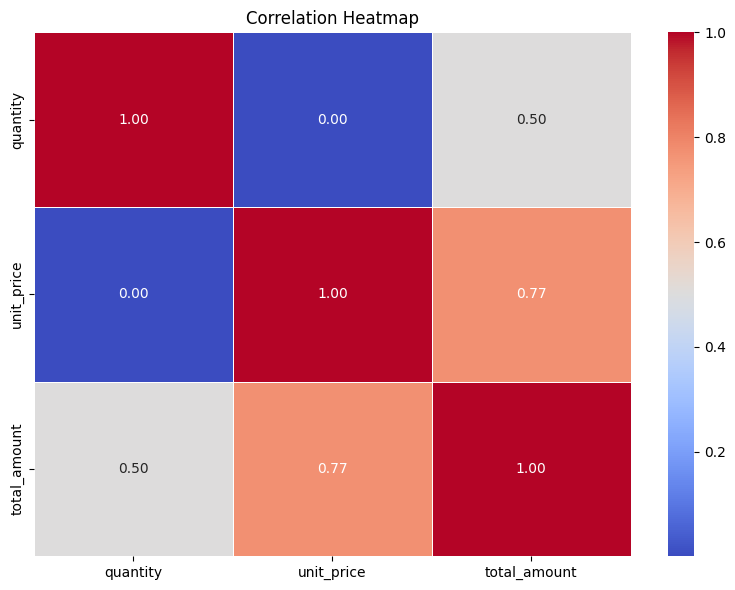

In [59]:
numeric_cols = df.select_dtypes(include="number")
plt.figure(figsize=(8, 6))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

* the correlation between unit price and total amount is very excepected since total amount is unit price multiply by quantity of product

### 7. Validating-Verification

In [60]:
df.isna().sum()

order_id          0
customer_id       0
order_date        0
country           0
category          0
product           0
quantity          0
unit_price        0
total_amount      0
status            0
payment_method    0
is_returned       0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49500 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        49500 non-null  string        
 1   customer_id     49500 non-null  string        
 2   order_date      49500 non-null  datetime64[ns]
 3   country         49500 non-null  string        
 4   category        49500 non-null  category      
 5   product         49500 non-null  string        
 6   quantity        49500 non-null  int64         
 7   unit_price      49500 non-null  float64       
 8   total_amount    49500 non-null  float64       
 9   status          49500 non-null  category      
 10  payment_method  49500 non-null  category      
 11  is_returned     49500 non-null  bool          
dtypes: bool(1), category(3), datetime64[ns](1), float64(2), int64(1), string(4)
memory usage: 3.6 MB


In [63]:
profile = data_profiling.ProfileReport(df, title="Profiling Report")
profile.to_file("report_clean_data.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 21.41it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## 7. Exporting Data

In [64]:
df.to_csv("cleaned_data.csv", index=False)